In [1]:
!pip install plotly-geo

In [3]:
!pip install geopandas --upgrade

In [4]:
import warnings 
warnings.filterwarnings("ignore")

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
import seaborn as sns
from scipy import stats
import plotly as py
import plotly.graph_objs as go
import geopandas as gpd
import plotly.express as px
import json
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

In [6]:
dt_wellness= pd.read_csv('wellness_business_dataset (1).csv')

In [7]:
dt_wellness

,Sales_Amount,Customer_Age,Transaction_Count,Product_Category,Region,Repeat_Customer,Income_Level,Customer_Lifetime_Value,Annual_Spend,Average_Discount_Utilized,Session_Duration_Minutes,Page_Views_per_Session,Ad_Clicks_per_Session,Products_Viewed_per_Session,Subscription_Status
0,109.934283,26,7,B,East,Yes,Low,12483.570770,2331.979201,21.721913,28.158542,4,6,1,Not_Subscribed
1,97.234714,62,3,B,North,Yes,Medium,9308.678494,797.044299,24.966395,18.698213,4,2,5,Not_Subscribed
2,112.953771,26,6,B,East,No,Medium,13238.442690,2069.692403,28.318823,32.730107,5,0,6,Subscribed
3,130.460597,43,2,C,North,No,Medium,17615.149280,999.491445,5.503446,9.253600,5,0,5,Not_Subscribed
4,95.316933,21,4,A,East,No,Low,8829.233126,4137.058445,8.844593,29.080432,6,2,2,Not_Subscribed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,121.403005,59,4,D,North,No,High,15350.751190,1774.779816,11.714973,36.604600,7,0,2,Not_Subscribed
1996,99.469575,23,4,D,North,No,Medium,9867.393704,2301.407763,17.370649,26.145068,4,9,4,Not_Subscribed
1997,82.362507,36,2,C,North,No,Low,5590.626744,4153.397558,7.152903,9.286228,4,0,2,Subscribed
1998,NaN,20,3,D,West,Yes,Low,9184.665180,562.379612,18.978416,41.677419,3,0,3,Not_Subscribed


In [8]:
dt_wellness.describe()

,Sales_Amount,Customer_Age,Transaction_Count,Customer_Lifetime_Value,Annual_Spend,Average_Discount_Utilized,Session_Duration_Minutes,Page_Views_per_Session,Ad_Clicks_per_Session,Products_Viewed_per_Session
count,1901.000000,2000.000000,2000.000000,1900.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,100.912552,40.522000,4.960500,10193.947060,2708.771395,17.490709,29.568050,5.066500,2.048500,3.943500
std,19.787991,13.454629,2.206666,4938.539437,1291.253298,7.260518,10.242955,2.324173,1.437422,1.940925
min,35.174653,18.000000,0.000000,-6206.336700,500.052356,5.005676,-2.210164,0.000000,0.000000,0.000000
25%,87.764618,29.000000,3.000000,6874.976957,1593.738645,11.183438,22.536795,3.000000,1.000000,3.000000
50%,100.928731,40.000000,5.000000,10183.167575,2703.354210,17.324246,29.479764,5.000000,2.000000,4.000000
75%,113.591955,52.000000,6.000000,13407.991980,3803.921885,23.908634,36.794819,7.000000,3.000000,5.000000
max,177.054630,64.000000,15.000000,29263.657450,4998.009665,29.986517,65.290552,15.000000,9.000000,13.000000


In [9]:
dt_wellness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Sales_Amount                 1901 non-null   float64
 1   Customer_Age                 2000 non-null   int64  
 2   Transaction_Count            2000 non-null   int64  
 3   Product_Category             2000 non-null   object 
 4   Region                       2000 non-null   object 
 5   Repeat_Customer              2000 non-null   object 
 6   Income_Level                 2000 non-null   object 
 7   Customer_Lifetime_Value      1900 non-null   float64
 8   Annual_Spend                 2000 non-null   float64
 9   Average_Discount_Utilized    2000 non-null   float64
 10  Session_Duration_Minutes     2000 non-null   float64
 11  Page_Views_per_Session       2000 non-null   int64  
 12  Ad_Clicks_per_Session        2000 non-null   int64  
 13  Products_Viewed_pe

In [10]:
# missing values
dt_wellness.isnull().sum()

Sales_Amount                    99
Customer_Age                     0
Transaction_Count                0
Product_Category                 0
Region                           0
Repeat_Customer                  0
Income_Level                     0
Customer_Lifetime_Value        100
Annual_Spend                     0
Average_Discount_Utilized        0
Session_Duration_Minutes         0
Page_Views_per_Session           0
Ad_Clicks_per_Session            0
Products_Viewed_per_Session      0
Subscription_Status              0
dtype: int64

In [11]:
# handling missing data with the mean method
# Imputation-Hot Deck-simpleImputer
dt_wellness_tr = dt_wellness.copy()
imp=SimpleImputer(strategy='mean', missing_values= np.nan)
dt_wellness_tr[['Sales_Amount_Tr']] =imp.fit_transform(dt_wellness_tr[['Sales_Amount']])

dt_wellness_tr.describe()

,Sales_Amount,Customer_Age,Transaction_Count,Customer_Lifetime_Value,Annual_Spend,Average_Discount_Utilized,Session_Duration_Minutes,Page_Views_per_Session,Ad_Clicks_per_Session,Products_Viewed_per_Session,Sales_Amount_Tr
count,1901.000000,2000.000000,2000.000000,1900.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,100.912552,40.522000,4.960500,10193.947060,2708.771395,17.490709,29.568050,5.066500,2.048500,3.943500,100.912552
std,19.787991,13.454629,2.206666,4938.539437,1291.253298,7.260518,10.242955,2.324173,1.437422,1.940925,19.291771
min,35.174653,18.000000,0.000000,-6206.336700,500.052356,5.005676,-2.210164,0.000000,0.000000,0.000000,35.174653
25%,87.764618,29.000000,3.000000,6874.976957,1593.738645,11.183438,22.536795,3.000000,1.000000,3.000000,88.468487
50%,100.928731,40.000000,5.000000,10183.167575,2703.354210,17.324246,29.479764,5.000000,2.000000,4.000000,100.912552
75%,113.591955,52.000000,6.000000,13407.991980,3803.921885,23.908634,36.794819,7.000000,3.000000,5.000000,112.763729
max,177.054630,64.000000,15.000000,29263.657450,4998.009665,29.986517,65.290552,15.000000,9.000000,13.000000,177.054630


In [12]:
dt_wellness_tr.isnull().sum()

Sales_Amount                    99
Customer_Age                     0
Transaction_Count                0
Product_Category                 0
Region                           0
Repeat_Customer                  0
Income_Level                     0
Customer_Lifetime_Value        100
Annual_Spend                     0
Average_Discount_Utilized        0
Session_Duration_Minutes         0
Page_Views_per_Session           0
Ad_Clicks_per_Session            0
Products_Viewed_per_Session      0
Subscription_Status              0
Sales_Amount_Tr                  0
dtype: int64

In [13]:
# handling missing data with the mean method
# Imputation-Hot Deck-simpleImputer
dt_wellness_tr = dt_wellness_tr.copy()
imp=SimpleImputer(strategy='mean', missing_values= np.nan)
dt_wellness_tr[['Customer_Lifetime_Value_Tr']] =imp.fit_transform(dt_wellness_tr[['Customer_Lifetime_Value']])

dt_wellness_tr.describe()

,Sales_Amount,Customer_Age,Transaction_Count,Customer_Lifetime_Value,Annual_Spend,Average_Discount_Utilized,Session_Duration_Minutes,Page_Views_per_Session,Ad_Clicks_per_Session,Products_Viewed_per_Session,Sales_Amount_Tr,Customer_Lifetime_Value_Tr
count,1901.000000,2000.000000,2000.000000,1900.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,100.912552,40.522000,4.960500,10193.947060,2708.771395,17.490709,29.568050,5.066500,2.048500,3.943500,100.912552,10193.947060
std,19.787991,13.454629,2.206666,4938.539437,1291.253298,7.260518,10.242955,2.324173,1.437422,1.940925,19.291771,4813.429458
min,35.174653,18.000000,0.000000,-6206.336700,500.052356,5.005676,-2.210164,0.000000,0.000000,0.000000,35.174653,-6206.336700
25%,87.764618,29.000000,3.000000,6874.976957,1593.738645,11.183438,22.536795,3.000000,1.000000,3.000000,88.468487,7037.942460
50%,100.928731,40.000000,5.000000,10183.167575,2703.354210,17.324246,29.479764,5.000000,2.000000,4.000000,100.912552,10193.947060
75%,113.591955,52.000000,6.000000,13407.991980,3803.921885,23.908634,36.794819,7.000000,3.000000,5.000000,112.763729,13193.134495
max,177.054630,64.000000,15.000000,29263.657450,4998.009665,29.986517,65.290552,15.000000,9.000000,13.000000,177.054630,29263.657450


In [14]:
dt_wellness_tr.isnull().sum()

Sales_Amount                    99
Customer_Age                     0
Transaction_Count                0
Product_Category                 0
Region                           0
Repeat_Customer                  0
Income_Level                     0
Customer_Lifetime_Value        100
Annual_Spend                     0
Average_Discount_Utilized        0
Session_Duration_Minutes         0
Page_Views_per_Session           0
Ad_Clicks_per_Session            0
Products_Viewed_per_Session      0
Subscription_Status              0
Sales_Amount_Tr                  0
Customer_Lifetime_Value_Tr       0
dtype: int64

In [15]:
dt_wellness_tr.describe(include='all')

,Sales_Amount,Customer_Age,Transaction_Count,Product_Category,Region,Repeat_Customer,Income_Level,Customer_Lifetime_Value,Annual_Spend,Average_Discount_Utilized,Session_Duration_Minutes,Page_Views_per_Session,Ad_Clicks_per_Session,Products_Viewed_per_Session,Subscription_Status,Sales_Amount_Tr,Customer_Lifetime_Value_Tr
count,1901.000000,2000.000000,2000.000000,2000,2000,2000,2000,1900.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000,2000.000000,2000.000000
unique,NaN,NaN,NaN,4,4,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
top,NaN,NaN,NaN,A,North,No,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Subscribed,NaN,NaN
freq,NaN,NaN,NaN,530,536,1011,739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1008,NaN,NaN
mean,100.912552,40.522000,4.960500,NaN,NaN,NaN,NaN,10193.947060,2708.771395,17.490709,29.568050,5.066500,2.048500,3.943500,NaN,100.912552,10193.947060
std,19.787991,13.454629,2.206666,NaN,NaN,NaN,NaN,4938.539437,1291.253298,7.260518,10.242955,2.324173,1.437422,1.940925,NaN,19.291771,4813.429458
min,35.174653,18.000000,0.000000,NaN,NaN,NaN,NaN,-6206.336700,500.052356,5.005676,-2.210164,0.000000,0.000000,0.000000,NaN,35.174653,-6206.336700
25%,87.764618,29.000000,3.000000,NaN,NaN,NaN,NaN,6874.976957,1593.738645,11.183438,22.536795,3.000000,1.000000,3.000000,NaN,88.468487,7037.942460
50%,100.928731,40.000000,5.000000,NaN,NaN,NaN,NaN,10183.167575,2703.354210,17.324246,29.479764,5.000000,2.000000,4.000000,NaN,100.912552,10193.947060
75%,113.591955,52.000000,6.000000,NaN,NaN,NaN,NaN,13407.991980,3803.921885,23.908634,36.794819,7.000000,3.000000,5.000000,NaN,112.763729,13193.134495


In [16]:
dt_wellness_tr

,Sales_Amount,Customer_Age,Transaction_Count,Product_Category,Region,Repeat_Customer,Income_Level,Customer_Lifetime_Value,Annual_Spend,Average_Discount_Utilized,Session_Duration_Minutes,Page_Views_per_Session,Ad_Clicks_per_Session,Products_Viewed_per_Session,Subscription_Status,Sales_Amount_Tr,Customer_Lifetime_Value_Tr
0,109.934283,26,7,B,East,Yes,Low,12483.570770,2331.979201,21.721913,28.158542,4,6,1,Not_Subscribed,109.934283,12483.570770
1,97.234714,62,3,B,North,Yes,Medium,9308.678494,797.044299,24.966395,18.698213,4,2,5,Not_Subscribed,97.234714,9308.678494
2,112.953771,26,6,B,East,No,Medium,13238.442690,2069.692403,28.318823,32.730107,5,0,6,Subscribed,112.953771,13238.442690
3,130.460597,43,2,C,North,No,Medium,17615.149280,999.491445,5.503446,9.253600,5,0,5,Not_Subscribed,130.460597,17615.149280
4,95.316933,21,4,A,East,No,Low,8829.233126,4137.058445,8.844593,29.080432,6,2,2,Not_Subscribed,95.316933,8829.233126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,121.403005,59,4,D,North,No,High,15350.751190,1774.779816,11.714973,36.604600,7,0,2,Not_Subscribed,121.403005,15350.751190
1996,99.469575,23,4,D,North,No,Medium,9867.393704,2301.407763,17.370649,26.145068,4,9,4,Not_Subscribed,99.469575,9867.393704
1997,82.362507,36,2,C,North,No,Low,5590.626744,4153.397558,7.152903,9.286228,4,0,2,Subscribed,82.362507,5590.626744
1998,NaN,20,3,D,West,Yes,Low,9184.665180,562.379612,18.978416,41.677419,3,0,3,Not_Subscribed,100.912552,9184.665180


In [17]:
dt_wellness_tr.head()

,Sales_Amount,Customer_Age,Transaction_Count,Product_Category,Region,Repeat_Customer,Income_Level,Customer_Lifetime_Value,Annual_Spend,Average_Discount_Utilized,Session_Duration_Minutes,Page_Views_per_Session,Ad_Clicks_per_Session,Products_Viewed_per_Session,Subscription_Status,Sales_Amount_Tr,Customer_Lifetime_Value_Tr
0,109.934283,26,7,B,East,Yes,Low,12483.570770,2331.979201,21.721913,28.158542,4,6,1,Not_Subscribed,109.934283,12483.570770
1,97.234714,62,3,B,North,Yes,Medium,9308.678494,797.044299,24.966395,18.698213,4,2,5,Not_Subscribed,97.234714,9308.678494
2,112.953771,26,6,B,East,No,Medium,13238.442690,2069.692403,28.318823,32.730107,5,0,6,Subscribed,112.953771,13238.442690
3,130.460597,43,2,C,North,No,Medium,17615.149280,999.491445,5.503446,9.253600,5,0,5,Not_Subscribed,130.460597,17615.149280
4,95.316933,21,4,A,East,No,Low,8829.233126,4137.058445,8.844593,29.080432,6,2,2,Not_Subscribed,95.316933,8829.233126


In [18]:
#A new column was created for numerical columns

num_columns=dt_wellness_tr[['Sales_Amount','Customer_Age','Transaction_Count','Customer_Lifetime_Value','Annual_Spend','Average_Discount_Utilized','Session_Duration_Minutes','Page_Views_per_Session','Ad_Clicks_per_Session','Products_Viewed_per_Session','Sales_Amount_Tr','Customer_Lifetime_Value_Tr']]

In [19]:
num_columns

,Sales_Amount,Customer_Age,Transaction_Count,Customer_Lifetime_Value,Annual_Spend,Average_Discount_Utilized,Session_Duration_Minutes,Page_Views_per_Session,Ad_Clicks_per_Session,Products_Viewed_per_Session,Sales_Amount_Tr,Customer_Lifetime_Value_Tr
0,109.934283,26,7,12483.570770,2331.979201,21.721913,28.158542,4,6,1,109.934283,12483.570770
1,97.234714,62,3,9308.678494,797.044299,24.966395,18.698213,4,2,5,97.234714,9308.678494
2,112.953771,26,6,13238.442690,2069.692403,28.318823,32.730107,5,0,6,112.953771,13238.442690
3,130.460597,43,2,17615.149280,999.491445,5.503446,9.253600,5,0,5,130.460597,17615.149280
4,95.316933,21,4,8829.233126,4137.058445,8.844593,29.080432,6,2,2,95.316933,8829.233126
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,121.403005,59,4,15350.751190,1774.779816,11.714973,36.604600,7,0,2,121.403005,15350.751190
1996,99.469575,23,4,9867.393704,2301.407763,17.370649,26.145068,4,9,4,99.469575,9867.393704
1997,82.362507,36,2,5590.626744,4153.397558,7.152903,9.286228,4,0,2,82.362507,5590.626744
1998,NaN,20,3,9184.665180,562.379612,18.978416,41.677419,3,0,3,100.912552,9184.665180


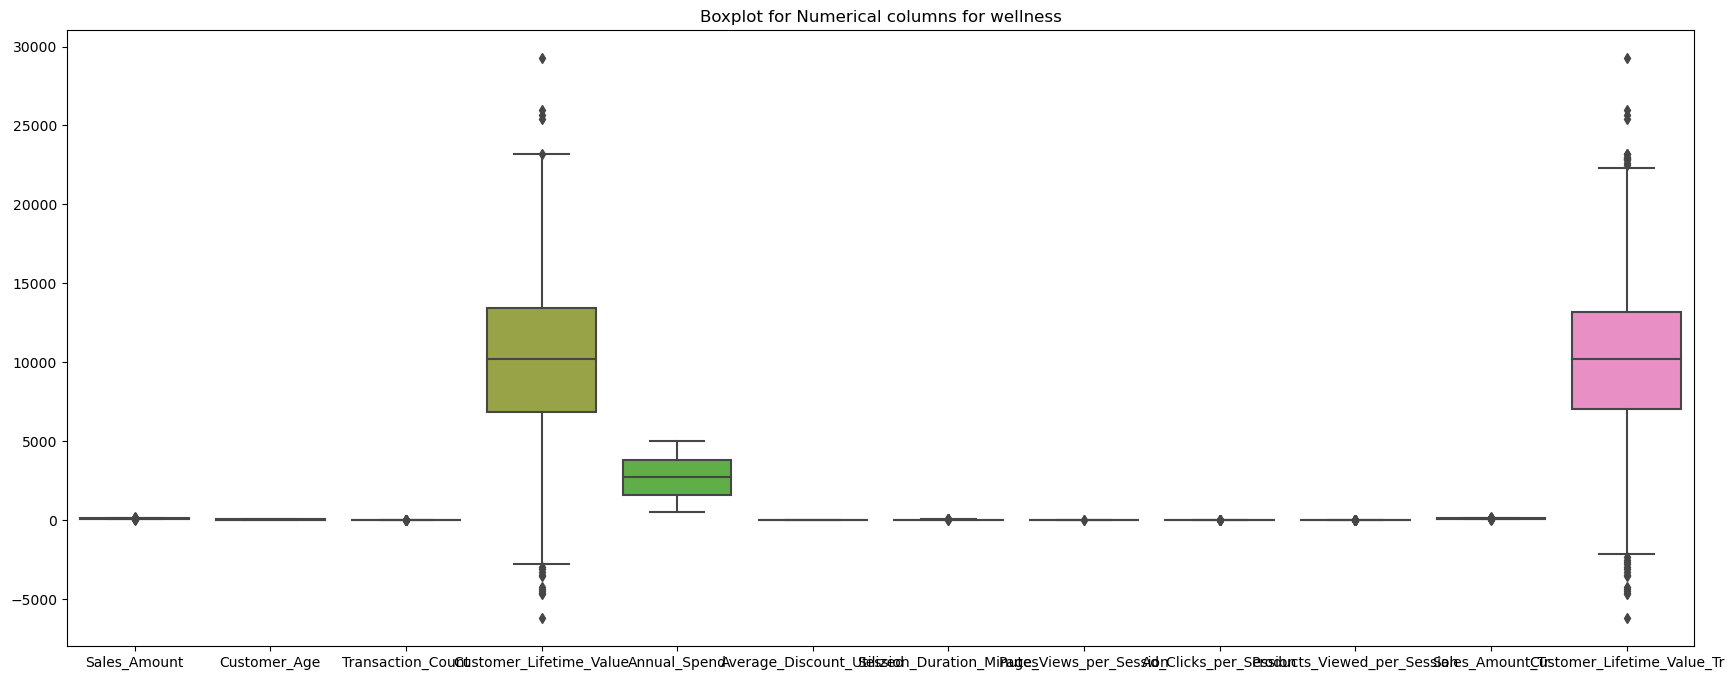

In [20]:
# Box plot to check outliers
plt.figure(figsize=(21,8))
sns.boxplot(data=num_columns[['Sales_Amount','Customer_Age','Transaction_Count','Customer_Lifetime_Value','Annual_Spend','Average_Discount_Utilized','Session_Duration_Minutes','Page_Views_per_Session','Ad_Clicks_per_Session','Products_Viewed_per_Session','Sales_Amount_Tr','Customer_Lifetime_Value_Tr']])
plt.title('Boxplot for Numerical columns for wellness')
plt.show()

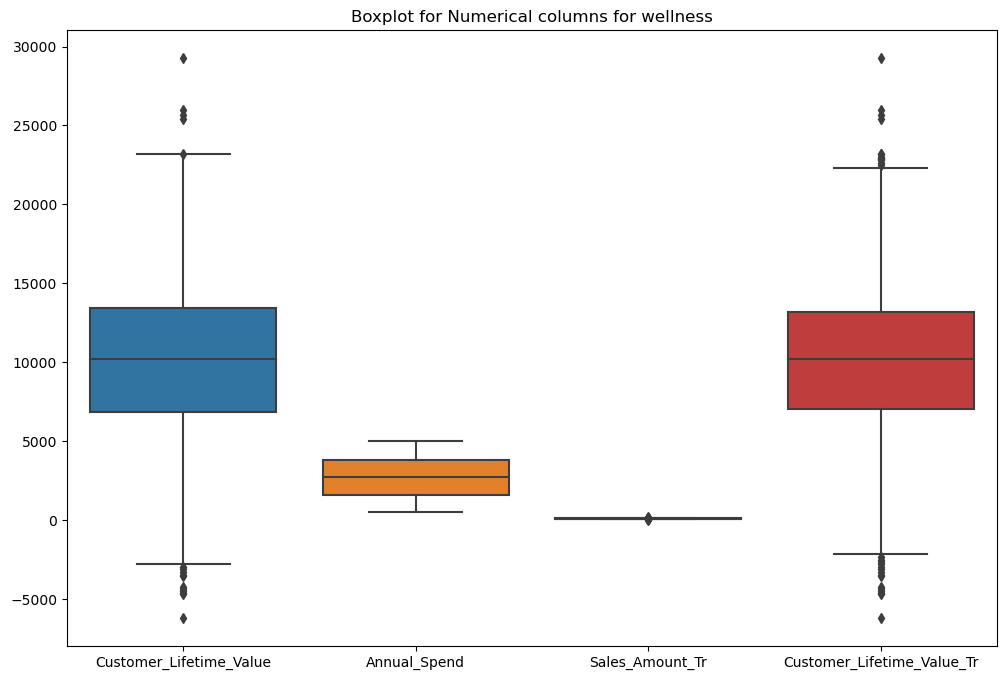

In [21]:
# Box plot to check outliers
plt.figure(figsize=(12,8))
sns.boxplot(data=num_columns[['Customer_Lifetime_Value','Annual_Spend','Sales_Amount_Tr','Customer_Lifetime_Value_Tr']])
plt.title('Boxplot for Numerical columns for wellness')
plt.show()

In [95]:
Customer_Lifetime_Value_Tr=dt_wellness_tr["Customer_Lifetime_Value_Tr"]
Customer_Lifetime_Value_Tr.describe()

count     2000.000000
mean     10193.947060
std       4813.429458
min      -6206.336700
25%       7037.942460
50%      10193.947060
75%      13193.134495
max      29263.657450
Name: Customer_Lifetime_Value_Tr, dtype: float64

In [93]:
Customer_Lifetime_Value_Tr.info()

<class 'pandas.core.series.Series'>
RangeIndex: 2000 entries, 0 to 1999
Series name: Customer_Lifetime_Value_Tr
Non-Null Count  Dtype  
--------------  -----  
2000 non-null   float64
dtypes: float64(1)
memory usage: 15.8 KB


In [102]:
# calculate the outliers for customer_Lifetime_value

z=np.abs(stats.zscore(dt_wellness_tr['Customer_Lifetime_Value_Tr']))

# I identify the outlier that is greater than 22000
threshold=22000
outliers=dt_wellness_tr['Customer_Lifetime_Value_Tr'][z > threshold]

# print outliers

print(outliers)

Series([], Name: Customer_Lifetime_Value_Tr, dtype: float64)


In [103]:
# to identify outliers

dt_wellness_tr['Customer_Lifetime_Value_Tr']>2200

0       True
1       True
2       True
3       True
4       True
        ... 
1995    True
1996    True
1997    True
1998    True
1999    True
Name: Customer_Lifetime_Value_Tr, Length: 2000, dtype: bool

# Q2.

In [100]:
dt_wellness_tr.describe()

,Sales_Amount,Customer_Age,Transaction_Count,Customer_Lifetime_Value,Annual_Spend,Average_Discount_Utilized,Session_Duration_Minutes,Page_Views_per_Session,Ad_Clicks_per_Session,Products_Viewed_per_Session,Sales_Amount_Tr,Customer_Lifetime_Value_Tr
count,1901.000000,2000.000000,2000.000000,1900.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,100.912552,40.522000,4.960500,10193.947060,2708.771395,17.490709,29.568050,5.066500,2.048500,3.943500,100.912552,10193.947060
std,19.787991,13.454629,2.206666,4938.539437,1291.253298,7.260518,10.242955,2.324173,1.437422,1.940925,19.291771,4813.429458
min,35.174653,18.000000,0.000000,-6206.336700,500.052356,5.005676,-2.210164,0.000000,0.000000,0.000000,35.174653,-6206.336700
25%,87.764618,29.000000,3.000000,6874.976957,1593.738645,11.183438,22.536795,3.000000,1.000000,3.000000,88.468487,7037.942460
50%,100.928731,40.000000,5.000000,10183.167575,2703.354210,17.324246,29.479764,5.000000,2.000000,4.000000,100.912552,10193.947060
75%,113.591955,52.000000,6.000000,13407.991980,3803.921885,23.908634,36.794819,7.000000,3.000000,5.000000,112.763729,13193.134495
max,177.054630,64.000000,15.000000,29263.657450,4998.009665,29.986517,65.290552,15.000000,9.000000,13.000000,177.054630,29263.657450


In [101]:
dt_wellness_tr

,Sales_Amount,Customer_Age,Transaction_Count,Product_Category,Region,Repeat_Customer,Income_Level,Customer_Lifetime_Value,Annual_Spend,Average_Discount_Utilized,Session_Duration_Minutes,Page_Views_per_Session,Ad_Clicks_per_Session,Products_Viewed_per_Session,Subscription_Status,Sales_Amount_Tr,Customer_Lifetime_Value_Tr
0,109.934283,26,7,B,East,Yes,Low,12483.570770,2331.979201,21.721913,28.158542,4,6,1,Not_Subscribed,109.934283,12483.570770
1,97.234714,62,3,B,North,Yes,Medium,9308.678494,797.044299,24.966395,18.698213,4,2,5,Not_Subscribed,97.234714,9308.678494
2,112.953771,26,6,B,East,No,Medium,13238.442690,2069.692403,28.318823,32.730107,5,0,6,Subscribed,112.953771,13238.442690
3,130.460597,43,2,C,North,No,Medium,17615.149280,999.491445,5.503446,9.253600,5,0,5,Not_Subscribed,130.460597,17615.149280
4,95.316933,21,4,A,East,No,Low,8829.233126,4137.058445,8.844593,29.080432,6,2,2,Not_Subscribed,95.316933,8829.233126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,121.403005,59,4,D,North,No,High,15350.751190,1774.779816,11.714973,36.604600,7,0,2,Not_Subscribed,121.403005,15350.751190
1996,99.469575,23,4,D,North,No,Medium,9867.393704,2301.407763,17.370649,26.145068,4,9,4,Not_Subscribed,99.469575,9867.393704
1997,82.362507,36,2,C,North,No,Low,5590.626744,4153.397558,7.152903,9.286228,4,0,2,Subscribed,82.362507,5590.626744
1998,NaN,20,3,D,West,Yes,Low,9184.665180,562.379612,18.978416,41.677419,3,0,3,Not_Subscribed,100.912552,9184.665180


In [105]:
# Statistics for Customer_Age
Customer_Age=dt_wellness_tr["Customer_Age"]
Customer_Age.describe()


count    2000.000000
mean       40.522000
std        13.454629
min        18.000000
25%        29.000000
50%        40.000000
75%        52.000000
max        64.000000
Name: Customer_Age, dtype: float64

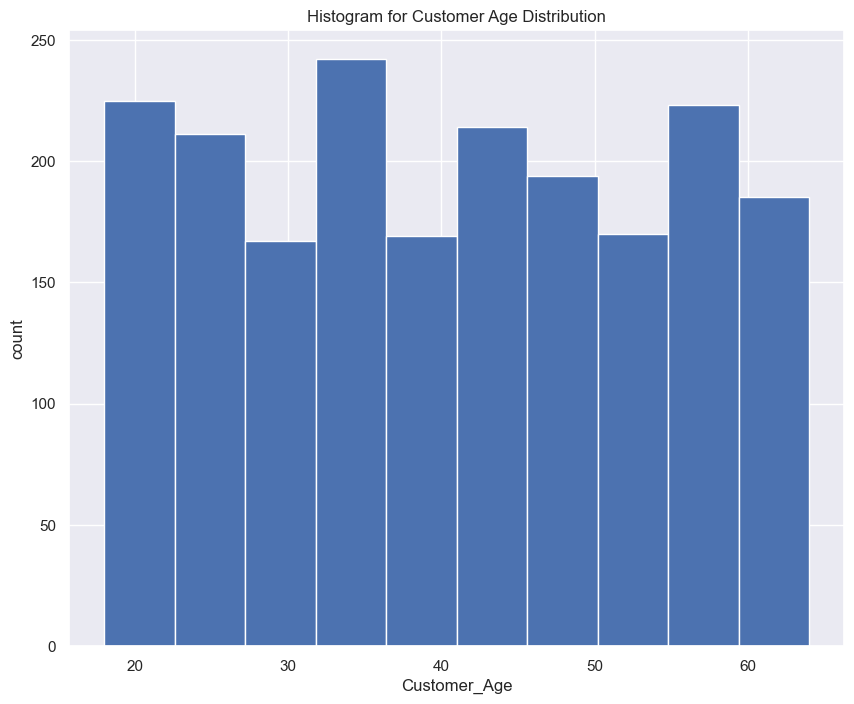

In [107]:
# customer age using a histogram

plt.hist(dt_wellness_tr['Customer_Age'],bins=10, )
plt.title('Histogram for Customer Age Distribution')
plt.xlabel('Customer_Age')
plt.ylabel('count')
plt.grid(True)
plt.show()
              
              

In [25]:
## Statistics of Session_Duration_Minutes

Session_Duration_Minutes=dt_wellness_tr["Session_Duration_Minutes"]
Session_Duration_Minutes

0       28.158542
1       18.698213
2       32.730107
3        9.253600
4       29.080432
          ...    
1995    36.604600
1996    26.145068
1997     9.286228
1998    41.677419
1999    22.249550
Name: Session_Duration_Minutes, Length: 2000, dtype: float64

In [26]:
Session_Duration_Minutes.describe()

count    2000.000000
mean       29.568050
std        10.242955
min        -2.210164
25%        22.536795
50%        29.479764
75%        36.794819
max        65.290552
Name: Session_Duration_Minutes, dtype: float64

<Axes: xlabel='Session_Duration_Minutes', ylabel='Density'>

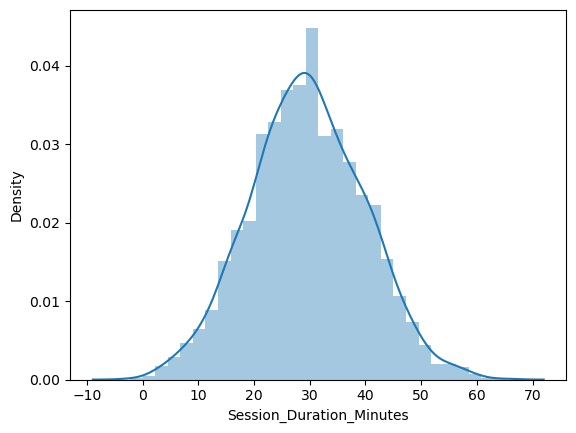

In [27]:

# The distribution of the data for Session_Duration_Minutes

sns.distplot(dt_wellness_tr.Session_Duration_Minutes)

In [28]:
# Statistics for Region

dt_wellness["Region"].describe()

count      2000
unique        4
top       North
freq        536
Name: Region, dtype: object

Text(0.5, 1.0, 'Countplot for Region Data')

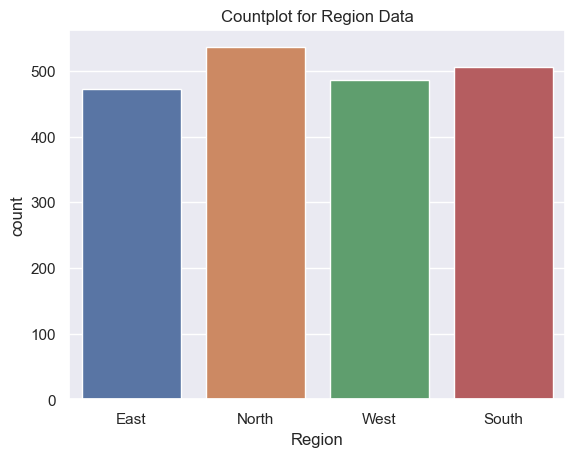

In [29]:
# visualisation of the regions of data wellness
sns.set_theme(style="darkgrid")
ax=sns.countplot(x="Region",data=dt_wellness_tr)
plt.title('Countplot for Region Data')

In [31]:
# Statistics for Subscription Status

dt_wellness["Subscription_Status"].describe()

count           2000
unique             2
top       Subscribed
freq            1008
Name: Subscription_Status, dtype: object

Text(0.5, 1.0, 'Countplot for Subsription_Status')

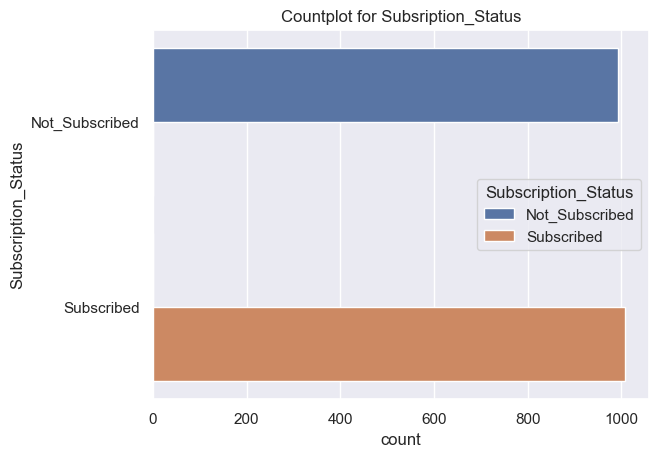

In [30]:
ax=sns.countplot( hue="Subscription_Status",y="Subscription_Status",data=dt_wellness_tr)
plt.title('Countplot for Subsription_Status')

Text(0.5, 1.0, 'Countplot for Subsription_Status')

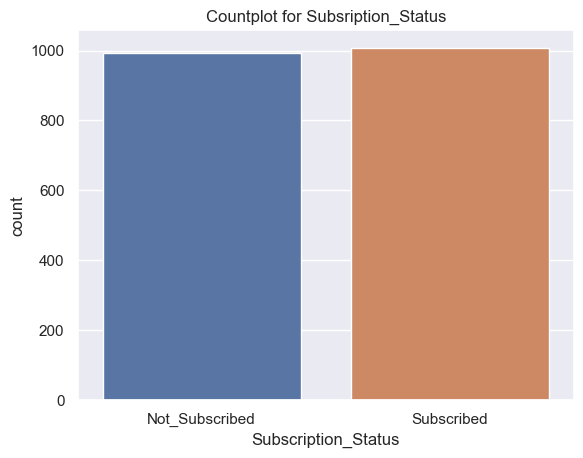

In [32]:
# Visualisation of the Subscription_Status
sns.set_theme(style="darkgrid")
ax=sns.countplot(x="Subscription_Status",data=dt_wellness_tr)
plt.title('Countplot for Subsription_Status')

In [33]:
dt_wellness_tr["Product_Category"].describe()

count     2000
unique       4
top          A
freq       530
Name: Product_Category, dtype: object

In [34]:
#product_category was count in numerical

Product_Category = dt_wellness_tr['Product_Category'].value_counts()


In [35]:
Product_Category

Product_Category
A    530
D    516
C    497
B    457
Name: count, dtype: int64

In [36]:
# Product_Category was describe
Product_Category.describe()

count      4.000000
mean     500.000000
std       31.696477
min      457.000000
25%      487.000000
50%      506.500000
75%      519.500000
max      530.000000
Name: count, dtype: float64

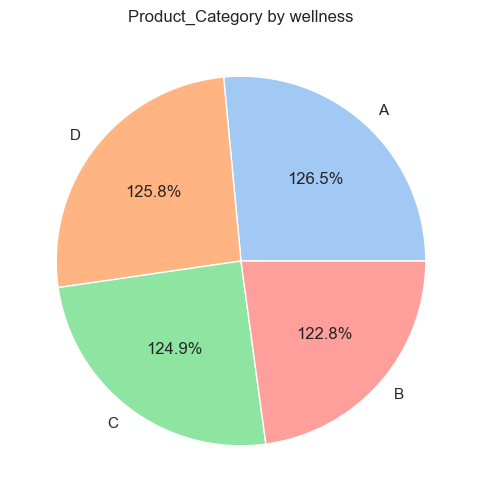

In [37]:
# Visualisation of Product_Category

# The color is defined

palette='pastel'

# pie chart was created
plt.figure(figsize=(6,6))
plt.pie(Product_Category,labels=Product_Category.index,autopct='1%.1f%%',
       colors=sns.color_palette(palette, len(Product_Category)))
plt.title('Product_Category by wellness')
plt.show()

In [38]:
dt_wellness_tr

,Sales_Amount,Customer_Age,Transaction_Count,Product_Category,Region,Repeat_Customer,Income_Level,Customer_Lifetime_Value,Annual_Spend,Average_Discount_Utilized,Session_Duration_Minutes,Page_Views_per_Session,Ad_Clicks_per_Session,Products_Viewed_per_Session,Subscription_Status,Sales_Amount_Tr,Customer_Lifetime_Value_Tr
0,109.934283,26,7,B,East,Yes,Low,12483.570770,2331.979201,21.721913,28.158542,4,6,1,Not_Subscribed,109.934283,12483.570770
1,97.234714,62,3,B,North,Yes,Medium,9308.678494,797.044299,24.966395,18.698213,4,2,5,Not_Subscribed,97.234714,9308.678494
2,112.953771,26,6,B,East,No,Medium,13238.442690,2069.692403,28.318823,32.730107,5,0,6,Subscribed,112.953771,13238.442690
3,130.460597,43,2,C,North,No,Medium,17615.149280,999.491445,5.503446,9.253600,5,0,5,Not_Subscribed,130.460597,17615.149280
4,95.316933,21,4,A,East,No,Low,8829.233126,4137.058445,8.844593,29.080432,6,2,2,Not_Subscribed,95.316933,8829.233126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,121.403005,59,4,D,North,No,High,15350.751190,1774.779816,11.714973,36.604600,7,0,2,Not_Subscribed,121.403005,15350.751190
1996,99.469575,23,4,D,North,No,Medium,9867.393704,2301.407763,17.370649,26.145068,4,9,4,Not_Subscribed,99.469575,9867.393704
1997,82.362507,36,2,C,North,No,Low,5590.626744,4153.397558,7.152903,9.286228,4,0,2,Subscribed,82.362507,5590.626744
1998,NaN,20,3,D,West,Yes,Low,9184.665180,562.379612,18.978416,41.677419,3,0,3,Not_Subscribed,100.912552,9184.665180


# Q3

In [39]:
Income_Level= dt_wellness_tr["Income_Level"]


In [108]:
# statistics for income level
Income_Level.describe()

count     2000
unique       3
top        Low
freq       739
Name: Income_Level, dtype: object

In [41]:
Products_Viewed_per_Session= dt_wellness_tr["Products_Viewed_per_Session"]

In [42]:
Products_Viewed_per_Session

0       1
1       5
2       6
3       5
4       2
       ..
1995    2
1996    4
1997    2
1998    3
1999    4
Name: Products_Viewed_per_Session, Length: 2000, dtype: int64

In [43]:
Subscription_Status=dt_wellness_tr["Subscription_Status"]

In [44]:
Subscription_Status.describe()

count           2000
unique             2
top       Subscribed
freq            1008
Name: Subscription_Status, dtype: object

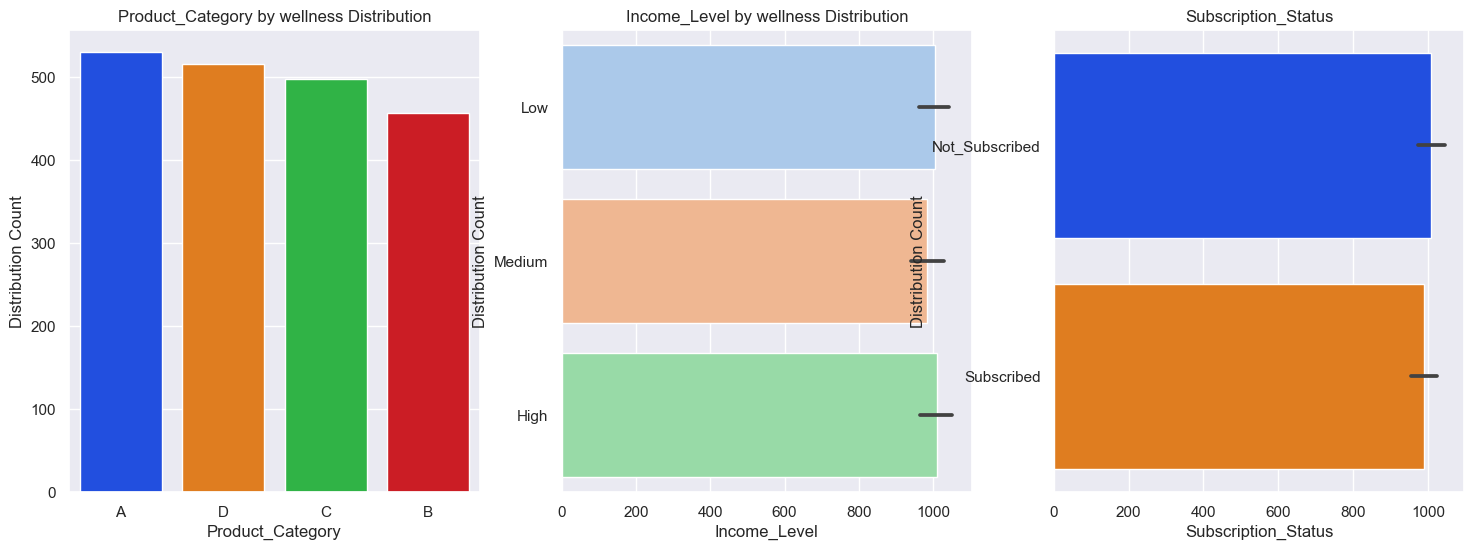

In [45]:
fig, ax = plt.subplots(1,3, figsize = (18, 6))
# Bar chart for product Category was created

sns.barplot(x=Product_Category.index, y =Product_Category.values, ax=ax[0], palette ='bright')
ax[0].set_title('Product_Category by wellness Distribution')
ax[0].set_xlabel('Product_Category')
ax[0].set_ylabel('Distribution Count')

# Bar chart for Income Level was created 

sns.barplot(x=Income_Level.index, y =Income_Level.values, ax=ax[1], palette ='pastel')
ax[1].set_title('Income_Level by wellness Distribution')
ax[1].set_xlabel('Income_Level')
ax[1].set_ylabel('Distribution Count')

# Bar Chart for product_Viewed per Session
sns.barplot(x=Subscription_Status.index, y =Subscription_Status.values, ax=ax[2], palette ='bright')
ax[2].set_title('Subscription_Status')
ax[2].set_xlabel('Subscription_Status')
ax[2].set_ylabel('Distribution Count')

plt.show()


In [46]:
Customer_Lifetime_Value_Tr=dt_wellness_tr["Customer_Lifetime_Value_Tr"]

In [47]:
Customer_Lifetime_Value_Tr.describe()

count     2000.000000
mean     10193.947060
std       4813.429458
min      -6206.336700
25%       7037.942460
50%      10193.947060
75%      13193.134495
max      29263.657450
Name: Customer_Lifetime_Value_Tr, dtype: float64

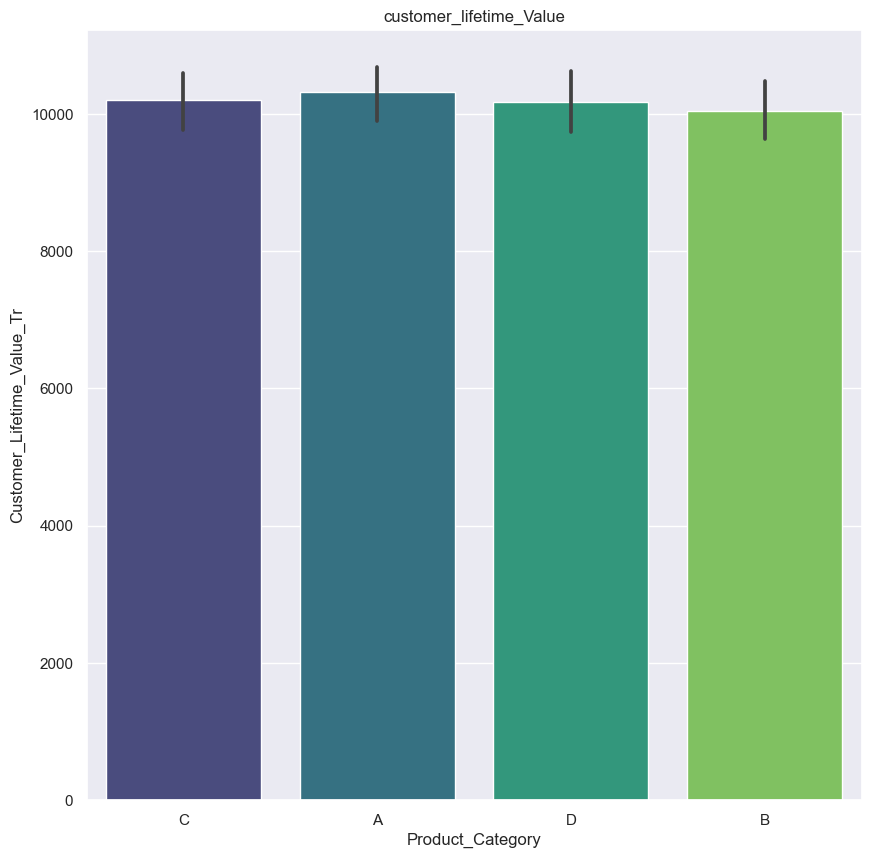

In [115]:
# Bar plot was created for Customer Lifetime and product category
sns.set(style = 'darkgrid')
plt.figure(figsize = (10,10))
bar_plot = sns.barplot(x = 'Product_Category', y='Customer_Lifetime_Value_Tr', data = dt_wellness_tr.sort_values('Customer_Lifetime_Value_Tr',ascending = False), 
                       palette = 'viridis')
bar_plot.set_title('customer_lifetime_Value')
bar_plot.set_xlabel('Product_Category')
bar_plot.set_ylabel('Customer_Lifetime_Value_Tr')
plt.show()

In [117]:
# statistics for Transaction_Count
Transaction_Count=dt_wellness_tr["Transaction_Count"]
Transaction_Count.describe()

count    2000.000000
mean        4.960500
std         2.206666
min         0.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        15.000000
Name: Transaction_Count, dtype: float64

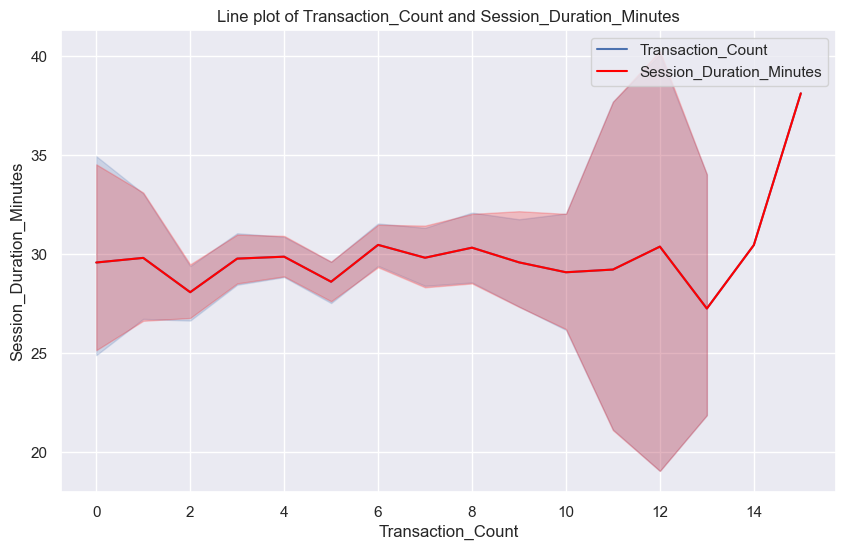

In [116]:
#Line plot
plt.figure(figsize=(10,6))
sns.lineplot(data=dt_wellness_tr,x='Transaction_Count',y='Session_Duration_Minutes',label='Transaction_Count')
sns.lineplot(data=dt_wellness_tr,x='Transaction_Count',y='Session_Duration_Minutes',color='red',label='Session_Duration_Minutes')

plt.title('Line plot of Transaction_Count and Session_Duration_Minutes')
plt.xlabel('Transaction_Count')
plt.ylabel('Session_Duration_Minutes')
plt.legend()
plt.show()

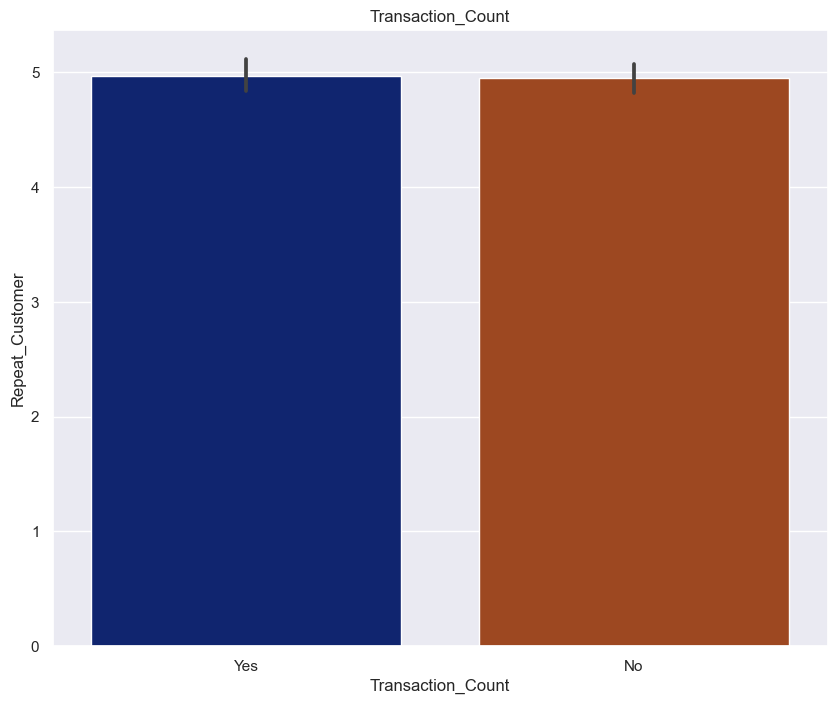

In [121]:
# Bar plot for Transaction and Repeat customer is Visualised
sns.set(style = 'darkgrid')
plt.figure(figsize = (10,8))
bar_plot = sns.barplot(x = 'Repeat_Customer', y='Transaction_Count', data = dt_wellness_tr.sort_values('Transaction_Count',ascending = False), 
                       palette = 'dark')
bar_plot.set_title('Transaction_Count')
bar_plot.set_xlabel('Transaction_Count')
bar_plot.set_ylabel('Repeat_Customer')
plt.show()

In [119]:
Repeat_Customer=dt_wellness_tr["Repeat_Customer"]
Repeat_Customer.describe()

count     2000
unique       2
top         No
freq      1011
Name: Repeat_Customer, dtype: object

In [52]:
Repeat_Customer

0       Yes
1       Yes
2        No
3        No
4        No
       ... 
1995     No
1996     No
1997     No
1998    Yes
1999    Yes
Name: Repeat_Customer, Length: 2000, dtype: object

In [53]:
Sales_Amount_Tr=dt_wellness_tr["Sales_Amount_Tr"]

In [124]:
Sales_Amount_Tr.describe()

count    2000.000000
mean      100.912552
std        19.291771
min        35.174653
25%        88.468487
50%       100.912552
75%       112.763729
max       177.054630
Name: Sales_Amount_Tr, dtype: float64

In [55]:
dt_wellness_tr

,Sales_Amount,Customer_Age,Transaction_Count,Product_Category,Region,Repeat_Customer,Income_Level,Customer_Lifetime_Value,Annual_Spend,Average_Discount_Utilized,Session_Duration_Minutes,Page_Views_per_Session,Ad_Clicks_per_Session,Products_Viewed_per_Session,Subscription_Status,Sales_Amount_Tr,Customer_Lifetime_Value_Tr
0,109.934283,26,7,B,East,Yes,Low,12483.570770,2331.979201,21.721913,28.158542,4,6,1,Not_Subscribed,109.934283,12483.570770
1,97.234714,62,3,B,North,Yes,Medium,9308.678494,797.044299,24.966395,18.698213,4,2,5,Not_Subscribed,97.234714,9308.678494
2,112.953771,26,6,B,East,No,Medium,13238.442690,2069.692403,28.318823,32.730107,5,0,6,Subscribed,112.953771,13238.442690
3,130.460597,43,2,C,North,No,Medium,17615.149280,999.491445,5.503446,9.253600,5,0,5,Not_Subscribed,130.460597,17615.149280
4,95.316933,21,4,A,East,No,Low,8829.233126,4137.058445,8.844593,29.080432,6,2,2,Not_Subscribed,95.316933,8829.233126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,121.403005,59,4,D,North,No,High,15350.751190,1774.779816,11.714973,36.604600,7,0,2,Not_Subscribed,121.403005,15350.751190
1996,99.469575,23,4,D,North,No,Medium,9867.393704,2301.407763,17.370649,26.145068,4,9,4,Not_Subscribed,99.469575,9867.393704
1997,82.362507,36,2,C,North,No,Low,5590.626744,4153.397558,7.152903,9.286228,4,0,2,Subscribed,82.362507,5590.626744
1998,NaN,20,3,D,West,Yes,Low,9184.665180,562.379612,18.978416,41.677419,3,0,3,Not_Subscribed,100.912552,9184.665180


In [56]:
# Statistics for Annual spend

Annual_Spend=dt_wellness_tr["Annual_Spend"]
Annual_Spend.describe()

count    2000.000000
mean     2708.771395
std      1291.253298
min       500.052356
25%      1593.738645
50%      2703.354210
75%      3803.921885
max      4998.009665
Name: Annual_Spend, dtype: float64

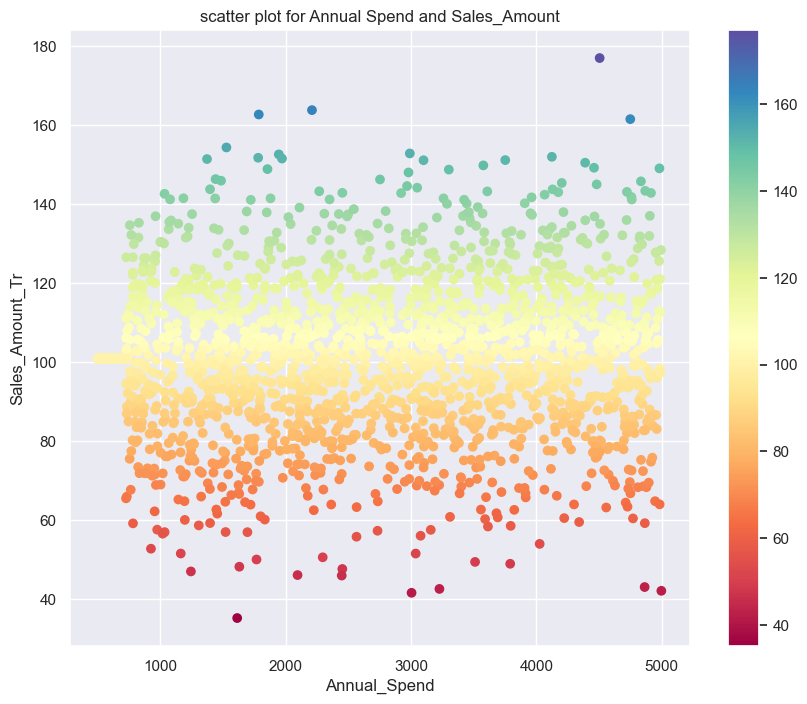

In [123]:
# Scatter plot for Annual_spend and Product_Category


x=dt_wellness_tr['Annual_Spend']
y=dt_wellness_tr['Sales_Amount_Tr']
plt.rcParams.update({'figure.figsize':(10,8),'figure.dpi':100})
plt.scatter(x,y, c=y, cmap='Spectral')
plt.colorbar()
plt.title('scatter plot for Annual Spend and Sales_Amount')
plt.xlabel('Annual_Spend')
plt.ylabel('Sales_Amount_Tr')
plt.show()

# Q3

In [58]:
Region =dt_wellness_tr["Region"]
Region

0        East
1       North
2        East
3       North
4        East
        ...  
1995    North
1996    North
1997    North
1998     West
1999     East
Name: Region, Length: 2000, dtype: object

In [59]:
Region.describe()

count      2000
unique        4
top       North
freq        536
Name: Region, dtype: object

In [60]:
Sales_Amount_Tr=dt_wellness_tr["Sales_Amount_Tr"]

In [61]:
Sales_Amount_Tr

0       109.934283
1        97.234714
2       112.953771
3       130.460597
4        95.316933
           ...    
1995    121.403005
1996     99.469575
1997     82.362507
1998    100.912552
1999     85.101947
Name: Sales_Amount_Tr, Length: 2000, dtype: float64

In [62]:
import folium

In [71]:
data=dict(type='choropleth',
         locations=['AK','NJ','OH','NY','LA','MD','TX','FL','CA'],
         locationmode='USA-states',
         colorscale='Jet',
         text=['Alaska','New Jersey','Ohio','New York','Lousiana','Maryland','Texas','Florida','California'],
         z=[200,300,400,500,600,700,800,900,1000],
          
         colorbar={'title':'Regional Sales Data'})

layout = dict(geo = {'scope': 'usa'})
choromap= go.Figure(data = [data], layout = layout)

choromap.show()
